In [141]:
!pip install -U langgraph langchain langchain_openai langchain-google-genai dotenv groq requests langchain-openrouter langchain_groq

  Using cached groq-1.5.0-py3-none-any.whl.metadata (16 kB)


In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = "add_your_api_key"
os.environ["GROQ_API_KEY"] = "add_your_api_key"
os.environ["OPENROUTER_API_KEY"] = "add_your_api_key"

In [143]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from langchain_openrouter import ChatOpenRouter

In [144]:
generator_llm = ChatGroq(model="llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(model="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model="llama-3.3-70b-versatile")
# evaluator_llm = ChatOpenRouter(model="deepseek/deepseek-r1")
# optimizer_llm = ChatOpenRouter(model="qwen/qwen3-32b")


In [145]:
# State
class TweetState(TypedDict):

  topic: str
  tweet: str
  evaluation: Literal["approved", "needs_approvement"]
  feedback: str
  iteration: int
  max_iteration: int

In [146]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
  evaluation: Literal["approved", "needs_approvement"] = Field(..., description='Final Evaluation')
  feedback: str = Field(..., description="Feed for the tweet")

In [147]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [148]:
def generate_tweet(state: TweetState) -> TweetState:

  # Prompt
  messages = [
      SystemMessage(content="You are a funny and clever Twitter/X influencer."),
      HumanMessage(content=f"""
      Write a short, original and hilarious tweet on the topic: "{state['topic']}".

      Rules:
      - Do not use question-answer format.
      - Max 280 characters
      - Use observational humor, irony, sarcasm or cultural references.
      - Think in meme, logic, punchlines, or relatable takes.
      - Use simple, day to day english.
      - This is version {state['iteration'] + 1}.
      """)
  ]

  # Send generator_llm
  response = generator_llm.invoke(messages).content

  # return response
  return {'tweet': response}

In [149]:
def evaluate_tweet(state: TweetState):

    messages = [
        SystemMessage(
            content=(
                "You are a ruthless, no-laugh-given Twitter critic. "
                "You evaluate tweets based on humor, originality, "
                "virality, and tweet format."
            )
        ),
        HumanMessage(
            content=f"""
Evaluate the following tweet:

Tweet:
"{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality
   Is this fresh, or have you seen it a hundred times before?

2. Humor
   Did it genuinely make you smile, laugh, or chuckle?

3. Punchiness
   Is it short, sharp, and scroll-stopping?

4. Virality Potential
   Would people retweet or share it?

5. Format
   Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- It ends with generic, throwaway, or deflating lines that weaken the humor

Respond ONLY in this format:

evaluation: approved | needs_improvement

feedback:
<One paragraph explaining the strengths and weaknesses>
"""
        ),
    ]

    response = structured_evaluator_llm.invoke(messages)
    return {'evaluation': response.evaluation, 'feedback': response.feedback}



In [150]:
def optimizer_tweet(state: TweetState):

    messages = [
        SystemMessage(
            content="You punch up tweets for virality and humour based on given feedback."
        ),
        HumanMessage(
            content=f"""
Improve the tweet based on this feedback:

Feedback:
"{state['feedback']}"

Topic:
"{state['topic']}"

Original Tweet:
"{state['tweet']}"

Rewrite it as a short, viral-worthy tweet.
Avoid Q&A style and stay under 280 characters.
"""
        )
    ]

    response = optimizer_llm.invoke(messages)

    iteration = state.get("iteration", 0) + 1

    return {
        "tweet": response.content,
        "iteration": iteration
    }

In [151]:
def route_evaluation(state: TweetState):
    evaluation = state["evaluation"]
    iteration = state["iteration"]
    max_iteration = state["max_iteration"]

    if evaluation == "approved" or iteration >= max_iteration:
        return "approved"
    else:
        return "needs_approvement"

In [152]:
graph = StateGraph(TweetState)
graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimizer_tweet', optimizer_tweet)


graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved': END  , 'needs_approvement': 'optimizer_tweet'})
graph.add_edge('optimizer_tweet', 'evaluate_tweet')

workflow = graph.compile()

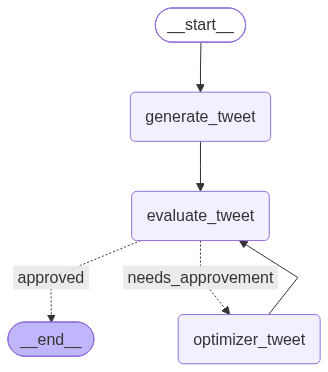

In [153]:
workflow

In [154]:
initial_state = {
      "topic": 'Indian Railways',
      "iteration": 1,
      "max_iteration": 5
}
messages = workflow.invoke(initial_state)
print("Messages : ", messages)

Messages :  {'topic': 'Indian Railways', 'tweet': '"Indian Railways: where \'delayed\' is just a polite way of saying \'it\'ll arrive when it feels like\' " #IndianRailways', 'evaluation': 'approved', 'feedback': "This tweet is a great example of a well-crafted joke. It has originality, as the comparison of 'delayed' to 'it'll arrive when it feels like' is a fresh take on a common experience. The humor is spot on, as it pokes fun at the notorious delays of Indian Railways in a lighthearted way. The punchiness is also excellent, with a short and sharp sentence that grabs the reader's attention. The tweet has high virality potential, as people who have experienced similar frustrations with Indian Railways will likely retweet and share it. The format is also well-formed, with a single sentence that is under 280 characters and doesn't follow a traditional setup-punchline structure. Overall, this tweet is a great example of how to craft a humorous and engaging tweet.", 'iteration': 1, 'max_